# 0. Import, device and hyper-parameters


In [7]:
import math
import utils
import torch
import torch.nn as nn
import torch.nn.functional as F


device = utils.try_gpu(0)
print(f"Use the {device} device")

DATA_PATH = "./data/cmn-eng/cmn.txt"

# Transformer 超参（5090 可再加大）；需保证 num_hiddens % num_heads == 0
num_hiddens, num_layers, dropout = 256, 2, 0.1
batch_size, num_steps = 256, 32
lr, num_epochs = 0.0005, 200
ffn_num_input, ffn_num_hiddens, num_heads = 256, 1024, 8
key_size = query_size = value_size = num_hiddens
norm_shape = [num_hiddens]


Use the cuda:0 device


# 1. Data loading and pre-processing


数据管道与 CH9 相同；此处直接复用 `utils` 中的实现（源/目标为「内容 + `<eos>`」，不含 `<bos>`）。


In [8]:
load_data_TdBSP = utils.load_data_TdBSP
preprocess_data = utils.preprocess_data
data_loader_TdBSP = utils.data_loader_TdBSP


In [9]:
Xs, Ys = load_data_TdBSP(DATA_PATH)
X, Y, X_vocab, Y_vocab = preprocess_data(Xs, Ys)

print(f"The first 5 words in the source sequence: \n{Xs[:5]}")
print(f"The first 5 words in the target sequence: \n{Ys[:5]}")
print(f"The vocabulary size of source sequence: {len(X_vocab)}, "
      f"The first 10 words in the vocabulary: \n{X_vocab.idx_to_token[:10]}")
print(f"The vocabulary size of target sequence: {len(Y_vocab)}, "
      f"The first 10 words in the vocabulary: \n{Y_vocab.idx_to_token[:10]}")

train_iter = data_loader_TdBSP(X, Y, batch_size, num_steps)


The first 5 words in the source sequence: 
[['Hi', '<eos>'], ['Hi', '<eos>'], ['Run', '<eos>'], ['Who', '<eos>'], ['Fire', '<eos>']]
The first 5 words in the target sequence: 
[['嗨', '<eos>'], ['你', '好', '<eos>'], ['你', '用', '跑', '的', '<eos>'], ['誰', '<eos>'], ['火', '<eos>']]
The vocabulary size of source sequence: 9551, The first 10 words in the vocabulary: 
['<unk>', '<bos>', '<eos>', 'I', 'to', 'the', 'you', 'a', 'is', 'Tom']
The vocabulary size of target sequence: 3726, The first 10 words in the vocabulary: 
['<unk>', '<bos>', '<eos>', '我', '的', '了', '你', '他', '不', '是']


# 2. Model and function


## 2.1 Attention building blocks


In [10]:
def masked_softmax(X, valid_lens):
    """在最后一个轴上按 valid_lens 做遮蔽后再 softmax。

    Args:
        X: 3D 分数张量，形状 (batch, num_queries, num_keys)。
        valid_lens: None，或 (batch,) / (batch, num_queries)。
    """
    if valid_lens is None:
        return F.softmax(X, dim=-1)
    shape = X.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    X = utils.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return F.softmax(X.reshape(shape), dim=-1)


class DotProductAttention(nn.Module):
    """缩放点积注意力。"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # queries/keys: (batch, n_q or n_kv, d); values: (batch, n_kv, v_dim)
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


In [11]:
def transpose_qkv(X, num_heads):
    """为多头并行计算变换形状。

    输入: (batch, seq, num_hiddens)
    输出: (batch*num_heads, seq, num_hiddens/num_heads)
    """
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])


def transpose_output(X, num_heads):
    """transpose_qkv 的逆操作。"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)


class MultiHeadAttention(nn.Module):
    """多头注意力。"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)
        output = self.attention(queries, keys, values, valid_lens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)


In [12]:
class PositionalEncoding(nn.Module):
    """正弦位置编码。"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1) / torch.pow(
            10000, torch.arange(0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)


## 2.2 Transformer blocks


In [13]:
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络。"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))


class AddNorm(nn.Module):
    """残差连接 + Dropout + LayerNorm。"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)


In [14]:
class EncoderBlock(nn.Module):
    """Transformer 编码器块：自注意力 + FFN。"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads,
            dropout, use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))


class TransformerEncoder(nn.Module):
    """Transformer 编码器。"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(
                f"block{i}",
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 嵌入缩放后与位置编码相加
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X


In [15]:
class DecoderBlock(nn.Module):
    """解码器中第 i 个块：掩蔽自注意力 + 交叉注意力 + FFN。"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练时整句并行；推理时逐步拼接历史表示
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values

        if self.training:
            batch_size, num_steps, _ = X.shape
            # 因果掩码：第 t 个查询只能看前 t 个键
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state


class TransformerDecoder(nn.Module):
    """Transformer 解码器。"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(
                f"block{i}",
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights


## 2.3 Loss, train and translate


In [16]:
def seq_mask(X, valid_len, value=0):
    X = X.clone()
    maxlen = X.size(1)
    mask = torch.arange(maxlen, dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X


class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带遮蔽的 softmax 交叉熵损失函数。"""
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = seq_mask(weights, valid_len)
        self.reduction = 'none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        return (unweighted_loss * weights).mean(dim=1)


class EncoderDecoder(nn.Module):
    """编码器-解码器外壳。"""
    def __init__(self, encoder, decoder):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, X_valid_len):
        enc_outputs = self.encoder(enc_X, X_valid_len)
        dec_state = self.decoder.init_state(enc_outputs, X_valid_len)
        return self.decoder(dec_X, dec_state)


In [17]:
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型（强制教学）。"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.Embedding:
            nn.init.normal_(m.weight, mean=0, std=0.01)

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = utils.AnimatorSimple(xlabel='epoch', ylabel='loss',
                                    xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = utils.Timer()
        metric = utils.Accumulator(2)
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)  # 强制教学
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            utils.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, '
          f'{metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')


In [18]:
def translate(net, src_sentence, src_vocab, tgt_vocab, num_steps, device):
    """贪心解码：英文 -> 中文（按字拼接）。"""
    net.eval()
    src_tokens = src_sentence.strip().split(' ')
    if src_tokens:
        src_tokens[-1] = src_tokens[-1][:-1]
    src_tokens = src_tokens + ['<eos>']
    src_ids = src_vocab[src_tokens]
    enc_valid_len = torch.tensor([len(src_ids)], device=device)

    pad = 0
    if len(src_ids) > num_steps:
        src_ids = src_ids[:num_steps]
    else:
        src_ids = src_ids + [pad] * (num_steps - len(src_ids))

    enc_X = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    dec_X = torch.tensor([[tgt_vocab['<bos>']]], dtype=torch.long, device=device)

    output_seq = []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        dec_X = Y.argmax(dim=2)
        pred = int(dec_X.squeeze(dim=0).item())
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ''.join(tgt_vocab.to_tokens(output_seq))


In [19]:
encoder = TransformerEncoder(
    len(X_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
decoder = TransformerDecoder(
    len(Y_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

# 形状冒烟测试
for batch in train_iter:
    Xb, Xlen, Yb, Ylen = [x.to(device) for x in batch]
    bos = torch.tensor([Y_vocab['<bos>']] * Yb.shape[0],
                       device=device).reshape(-1, 1)
    dec_in = torch.cat([bos, Yb[:, :-1]], 1)
    net.to(device)
    Y_hat, _ = net(Xb, dec_in, Xlen)
    print('Y_hat shape:', tuple(Y_hat.shape))  # (B, T, vocab)
    break


Y_hat shape: (256, 32, 3726)


# 3. Training and generation


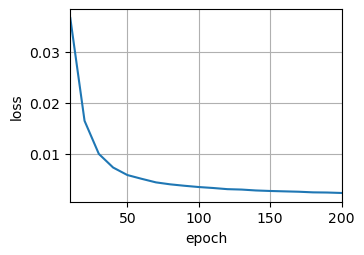

loss 0.002, 157681.3 tokens/sec on cuda:0


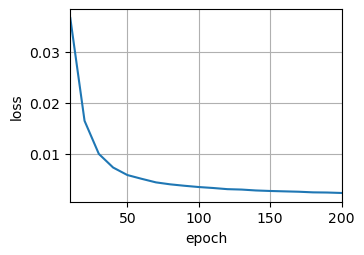

In [20]:
train_seq2seq(net, train_iter, lr, num_epochs, Y_vocab, device)


In [23]:
engs = ['Hi.', 'I won!', 'Hello!', 'I lost.', "I'm home.", "Fuck you."]
for eng in engs:
    print(f'{eng} => {translate(net, eng, X_vocab, Y_vocab, num_steps, device)}')


Hi. => 嗨
I won! => 我赢了
Hello! => 你好
I lost. => 我迷失了
I'm home. => 我在家裡
Fuck you. => 开始
